# 11. 強固に結合するのに分単位で応答できる謎 — Hfq 上の能動的 RNA 交換

> **出典**: Park S, Prevost K, Heideman EM, et al. (2021) *Dynamic interactions between the RNA chaperone Hfq, small regulatory RNAs, and mRNAs in live bacterial cells.* eLife 10:e64207.

単一分子ライブセル観察で分かったこと:

- 通常増殖時、**Hfq はほとんど mRNA に占有**されている（distal 面）。Hfq は量が律速。
- in vitro では sRNA-Hfq / mRNA-Hfq の寿命は **>100 分**（ほとんど外れない）。なのにストレス時、
  sRNA は**数分**で標的を制御しはじめる。占有済みの Hfq に、どうやってそんなに素早く乗るのか？
- 答え: 空くのを待つ（passive）のではなく、**入ってきた sRNA が結合済み mRNA を直接追い出す
  能動交換（active exchange）**。これで分単位の応答が可能になる。

## モデル（純粋な結合速度論）

| 反応 | 意味 |
|---|---|
| $m+H\rightleftharpoons mH,\ \ s+H\rightleftharpoons sH$ | Hfq への結合（$k_{off}=0.01/\mathrm{min}$ = ~70分寿命の強固な結合） |
| $mH+s\rightleftharpoons sH+m$ | **能動交換**（active のみ）: sRNA が結合済み mRNA を置換 |

事前状態: Hfq は全て mRNA に占有（$mH=10$）、余剰 mRNA=90。t=0 で sRNA=20 を誘導し、
機能型 $sH$ が立ち上がる速さを passive と active で比べる。

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from ecell4 import run_simulation
from ecell4_base.core import NetworkModel, ReactionRule, Species

H, M, S, MH, SH = (Species(x) for x in ['H','m','s','mH','sH'])
K_ON, K_OFF = 0.1, 0.01
SP = ['H','m','s','mH','sH']
def R(a,b,k): return ReactionRule(a,b,k)

def build(k_ex):
    rules = [R([M,H],[MH],K_ON), R([MH],[M,H],K_OFF), R([S,H],[SH],K_ON), R([SH],[S,H],K_OFF)]
    if k_ex > 0:
        rules += [R([MH,S],[SH,M],k_ex), R([SH,M],[MH,S],k_ex)]
    mdl = NetworkModel()
    for r in rules: mdl.add_reaction_rule(r)
    return mdl

def traj(k_ex, t_end=60.0, ndiv=120):
    return run_simulation(t_end, y0={'mH':10.,'m':90.,'s':20.}, model=build(k_ex),
                          solver='ode', ndiv=ndiv, species_list=SP).as_array()
print('ready')

ready


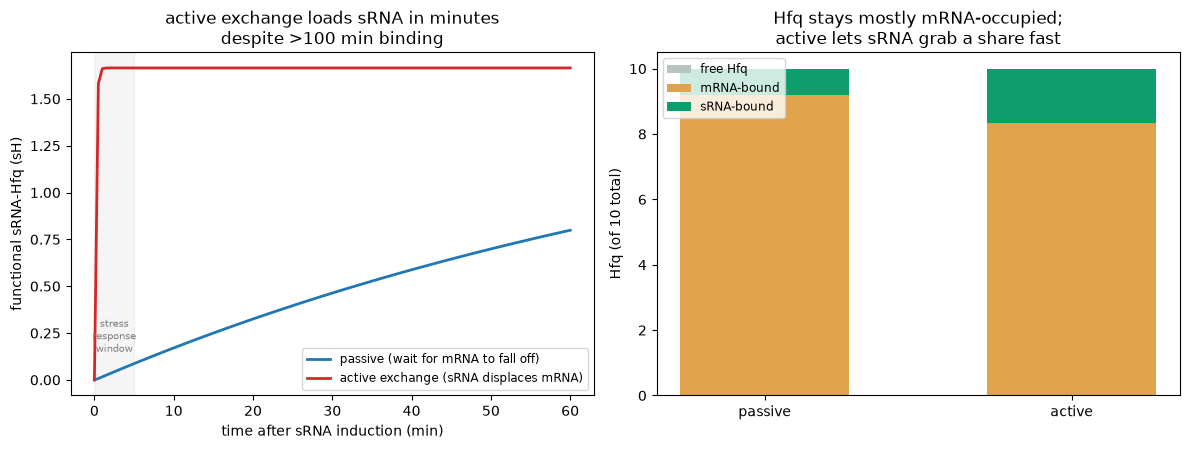

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))

for k_ex, c, lab in [(0.0,'C0','passive (wait for mRNA to fall off)'),
                     (0.05,'C3','active exchange (sRNA displaces mRNA)')]:
    a = traj(k_ex)
    ax1.plot(a[:,0], a[:,5], '-', color=c, lw=2, label=lab)   # sH
ax1.axvspan(0, 5, color='gray', alpha=.08)
ax1.text(2.5, 0.15, 'stress\nresponse\nwindow', ha='center', fontsize=7.5, color='gray')
ax1.set_xlabel('time after sRNA induction (min)'); ax1.set_ylabel('functional sRNA-Hfq (sH)')
ax1.set_title('active exchange loads sRNA in minutes\ndespite >100 min binding'); ax1.legend(fontsize=8.5)

for i,(k_ex,lab) in enumerate([(0.0,'passive'),(0.05,'active')]):
    v = dict(zip(SP, traj(k_ex)[-1][1:])); bottom = 0
    for key,col,klab in [('H','#b8c4be','free Hfq'),('mH','#e0a24b','mRNA-bound'),('sH','#0e9e6e','sRNA-bound')]:
        ax2.bar(i, v[key], bottom=bottom, color=col, width=.55, label=klab if i==0 else None); bottom += v[key]
ax2.set_xticks([0,1]); ax2.set_xticklabels(['passive','active'])
ax2.set_ylabel('Hfq (of 10 total)')
ax2.set_title('Hfq stays mostly mRNA-occupied;\nactive lets sRNA grab a share fast'); ax2.legend(fontsize=8.5, loc='upper left')
plt.tight_layout(); plt.show()

## 読み取り

- **左**: 能動交換（赤）は応答窓（~数分）の内に機能型 $sH$ を立ち上げる。passive（青）は mRNA が自然に外れるのを
  待つしかなく、60分たっても半分も届かない。**「強固な結合」と「素早い応答」の矛盾を、能動交換が解く。**
- **右**: どちらでも Hfq は**大半が mRNA 占有**のまま（mRNA が多数だから）——ライブセルの観察と一致。
  だが能動交換があると、sRNA はその中でも**必要な分をすばやく確保**できる。

**06〜10 との関係**: これまで「結合の平衡」で語ってきたが、11 は**動態（速さ）**そのものが主役。
同じ平衡に達するにも、passive か active かで応答時間が桁で変わる——ストレス応答という時間制約のある場面で決定的。

**この論文のもう一つの発見（発展）**: Hfq が distal 面で特定 mRNA に結合すると **RNase E を呼び込み、
sRNA 非依存に mRNA を分解**する。そして distal 面に強く結合する sRNA は、この働きを**デコイ**して逸らせる。

## 練習問題

1. `k_ex` を 0→0.2 に振り、応答時間（$sH$ が最終値の半分に達する時刻）がどう縮むかを測る。
2. 結合をもっと強固に（`K_OFF`=0.001）すると、passive と active の差はどこまで開くか。
3. 上の「RNase E デコイ」を最小モデル化: `mRNA + Hfq(distal) -> RNase E 呼び込み -> mRNA 分解`、
   そこへ distal 結合 sRNA を入れて分解が抑えられる（デコイ）ことを示す。
4. [[bio-a_hfq-phylogenetics]]: 能動交換のしやすさは Hfq の rim / C 末端テールに依存する。
   これらの領域の配列進化を「応答の速さ」の差として解釈してみる。